# 02 · Weak (Integral) SINDy

The weakness of vanilla SINDy is the pointwise derivative $\dot X$. **Weak SINDy**
avoids it by multiplying the dynamics by smooth, compactly-supported **test functions**
$\phi_k$ and integrating by parts over many subdomains:

$$\int \phi_k\,\dot X \,dt \;=\; -\int \dot\phi_k\, X\,dt \;=\; \int \phi_k\,\Theta(X)\,dt\;\Xi .$$

The derivative now lands on the *known* test function $\phi_k$, not on noisy data — so
the formulation is **orders of magnitude more robust to noise**. We use `pysindy`'s
`WeakPDELibrary` (configured for an ODE: the only grid dimension is time).

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sparse_demos import systems
import pysindy as ps

# Same Lotka-Volterra system, but now with substantial noise.
NOISE = 1.0
tn, Xn = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01,
                          noise_std=NOISE, seed=3)
dt = tn[1] - tn[0]

## Vanilla vs. Weak at the same noise level

In [4]:
# Vanilla SINDy on the noisy data
vanilla = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                   optimizer=ps.STLSQ(threshold=0.05))
vanilla.fit(Xn, t=dt, feature_names=["x", "y"])
print(f"=== Vanilla SINDy  (noise std={NOISE}) ===")
vanilla.print()

# Weak SINDy on the SAME data
weak_lib = ps.WeakPDELibrary(
    function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
    spatiotemporal_grid=tn, is_uniform=True, K=200,
)
weak = ps.SINDy(feature_library=weak_lib, optimizer=ps.STLSQ(threshold=0.05))
weak.fit(Xn, t=dt, feature_names=["x", "y"])
print(f"\n=== Weak SINDy    (noise std={NOISE}) ===")
weak.print()
print("\nTrue:  (x)' = 1.0 x - 0.1 x y     (y)' = -1.5 y + 0.075 x y")

=== Vanilla SINDy  (noise std=1.0) ===
(x)' =  0.171 1 +  0.952 x + -0.102 y + -0.092 x y
(y)' =  0.798 1 + -1.540 y +  0.073 x y

=== Weak SINDy    (noise std=1.0) ===
(x)' =  1.002 x + -0.100 x y
(y)' = -1.499 y +  0.075 x y

True:  (x)' = 1.0 x - 0.1 x y     (y)' = -1.5 y + 0.075 x y


## A systematic noise sweep

We sweep the noise level and measure the relative coefficient error of each method
against the known ground truth.

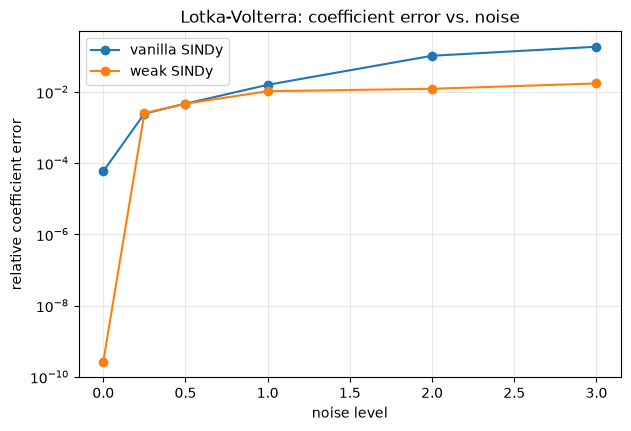

vanilla SINDy ['0.000', '0.002', '0.005', '0.016', '0.104', '0.185']
weak SINDy ['0.000', '0.003', '0.005', '0.010', '0.012', '0.017']


In [5]:
from sparse_demos import metrics, plotting

# Ground-truth coefficient vector for the active terms [x, xy] and [y, xy].
TRUE = {"x": 1.0, "x y": -0.1, "y": -1.5, "x y_y": 0.075}

def coef_dict(model):
    names = model.get_feature_names()
    C = model.coefficients()
    return names, C

def rel_error(model):
    names, C = coef_dict(model)
    # locate library indices for x, y, x y
    idx = {n: names.index(n) for n in ["x", "y", "x y"] if n in names}
    est = np.array([C[0, idx.get("x", 0)], C[0, idx.get("x y", 0)],
                    C[1, idx.get("y", 0)], C[1, idx.get("x y", 0)]])
    true = np.array([1.0, -0.1, -1.5, 0.075])
    return metrics.coef_l2_error(true, est)

noise_levels = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]
errs = {"vanilla SINDy": [], "weak SINDy": []}
for nz in noise_levels:
    tt, XX = systems.simulate("lotka_volterra", t_span=(0, 20), dt=0.01,
                              noise_std=nz, seed=7)
    ddt = tt[1] - tt[0]
    v = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2),
                 optimizer=ps.STLSQ(threshold=0.05))
    v.fit(XX, t=ddt, feature_names=["x", "y"])
    wl = ps.WeakPDELibrary(function_library=ps.PolynomialLibrary(degree=2, include_bias=True),
                           spatiotemporal_grid=tt, is_uniform=True, K=200)
    w = ps.SINDy(feature_library=wl, optimizer=ps.STLSQ(threshold=0.05))
    w.fit(XX, t=ddt, feature_names=["x", "y"])
    errs["vanilla SINDy"].append(rel_error(v))
    errs["weak SINDy"].append(rel_error(w))

plotting.plot_noise_sweep(noise_levels, errs,
                          title="Lotka-Volterra: coefficient error vs. noise")
plt.show()
for k, v in errs.items():
    print(k, ["%.3f" % e for e in v])

**Takeaway.** The weak form keeps recovering accurate coefficients well into noise
levels where vanilla SINDy's error explodes — at the cost of choosing test-function
settings (`K`, the number of subdomains). Next: dynamics that are **rational**, which
*no* polynomial library can express. → `03_sindy_pi.ipynb`